#Reading Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
workDir = os.path.join(os.getcwd(),"drive/MyDrive/Colab Notebooks/Graph Sentiment Analysis")

In [6]:
dataPath = os.path.join(workDir,"Twitter_Data.csv")
dataset = pd.read_csv(dataPath)

In [7]:
dataset.head(10)

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
5,kiya tho refresh maarkefir comment karo,0.0
6,surat women perform yagna seeks divine grace f...,0.0
7,this comes from cabinet which has scholars lik...,0.0
8,with upcoming election india saga going import...,1.0
9,gandhi was gay does modi,1.0


In [8]:
dataset = dataset.dropna(axis=0)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162969 non-null  object 
 1   category    162969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.7+ MB


In [9]:
dataset = dataset.astype({"category":int})

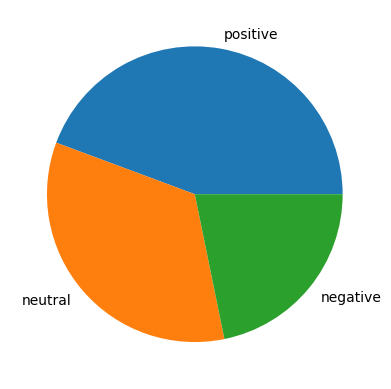

In [10]:
plt.pie(dataset["category"].value_counts(),labels=["positive","neutral","negative"])
plt.show()

In [11]:
dataset.shape

(162969, 2)

#Preproccesing

In [12]:
import nltk
nltk.download("wordnet")

from nltk.tokenize import RegexpTokenizer
regex_tokenizer  = RegexpTokenizer(r"\w+")

from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [13]:
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
len(stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


179

In [14]:
def sentence_preprocess (sentence : str) -> list :
    sentence = sentence.lower()

    # tokenization
    tokens = regex_tokenizer.tokenize(sentence)
    # removing digits
    tokens  = [ token for token in tokens if not token.isdigit() ]

    # removing stop-words or spaces
    tokens = [ word for word in tokens if (word not in stop_words) and (word != " ") ]

    # lemmatization
    lemmas = [wnl.lemmatize(token) for token in tokens]

    return " ".join(lemmas)

In [15]:
# for testing
sent = dataset["clean_text"][0]
print ( sentence_preprocess(sent) )

modi promised minimum government maximum governance expected begin difficult job reforming state take year get justice state business exit psus temple


In [21]:
pre_dataset  = pd.concat( [  dataset["clean_text"].apply(lambda sent : sentence_preprocess(sent)) , dataset["category"]], axis=1, ignore_index= True)
pre_dataset = pre_dataset.rename({0:"preprocessed_text", 1 : "target"},axis = 1)
pre_dataset.head()

,preprocessed_text,target
0,modi promised minimum government maximum gover...,-1
1,talk nonsense continue drama vote modi,0
2,say vote modi welcome bjp told rahul main camp...,1
3,asking supporter prefix chowkidar name modi gr...,1
4,answer among powerful world leader today trump...,1


In [22]:
from wordcloud import WordCloud
wc = WordCloud(background_color="white")

In [26]:
def get_words (data : pd.DataFrame ,target : int) -> str:
    for x, y in data.groupby(by = ["target"]) :
        if x == target :
            return  " ".join(list(y["preprocessed_text"]))


def generate_wordcloud (data : pd.DataFrame , target : int ,word_cloud_obj : WordCloud ):
    return word_cloud_obj.generate( get_words(data, target) )

In [27]:
get_words(pre_dataset, -1)

Output hidden; open in https://colab.research.google.com to view.

<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :


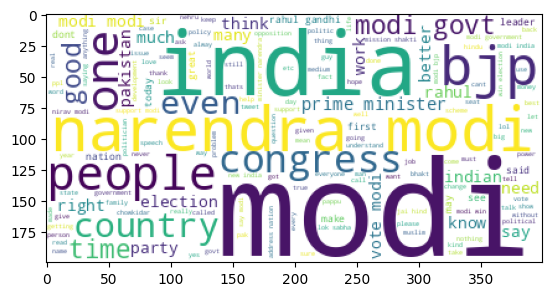

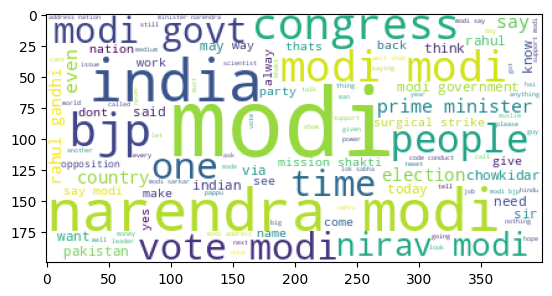

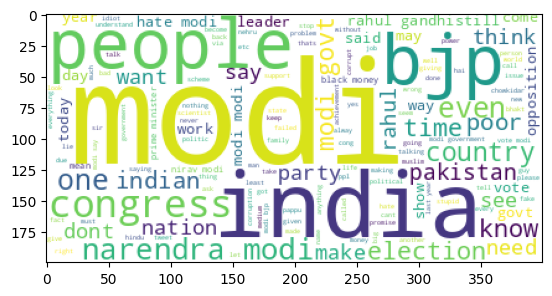

In [28]:
#for positive comments
plt.figure(1)
plt.imshow(generate_wordcloud(
    pre_dataset,
    1,
    wc,
))
#for neutral comments
plt.figure(2)
plt.imshow(generate_wordcloud(
    pre_dataset,
    0,
    wc
), )
#for negative comments
plt.figure(3)
plt.imshow(generate_wordcloud(
    pre_dataset,
    -1,
    wc
))
plt.show()

In [29]:
from collections import Counter

In [30]:
#for positive comments
posi_comm = Counter(get_words(pre_dataset, 1).split())
#for neutral comments
neu_comm = Counter(get_words(pre_dataset, 0).split())
#for negative comments
neg_comm = Counter(get_words(pre_dataset, -1).split())

<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :


In [31]:
#getting common stopwords
common_stop_words = (posi_comm & neu_comm & neg_comm).most_common(150) + (posi_comm & neg_comm).most_common(150)
common_stop_words = [x for x,y in common_stop_words]
len(common_stop_words)

300

In [32]:
pre_dataset["preprocessed_text"] = pre_dataset["preprocessed_text"].apply(
    lambda sent : " ".join (list(
        filter(lambda word : word not in common_stop_words, sent.split())
    ))
)

In [33]:
pre_dataset.head(10)

,preprocessed_text,target
0,promised minimum maximum governance expected b...,-1
1,nonsense continue drama,0
2,welcome told main campaigner relax,1
3,asking prefix great service confusion read cru...,1
4,answer among powerful trump putin,1
5,kiya tho refresh maarkefir comment karo,0
6,surat woman perform yagna seek divine grace,0
7,cabinet scholar smriti hema introspect,0
8,upcoming saga important pair current lead elec...,1
9,gay,1


<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :
<ipython-input-26-34ab8c6fee9e>:2: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for x, y in data.groupby(by = ["target"]) :


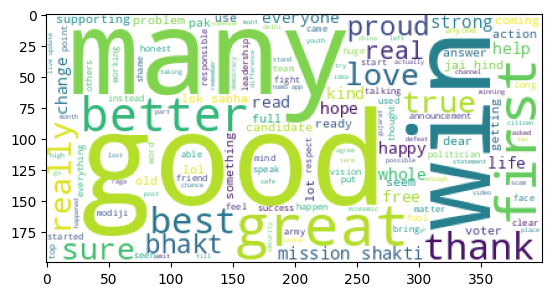

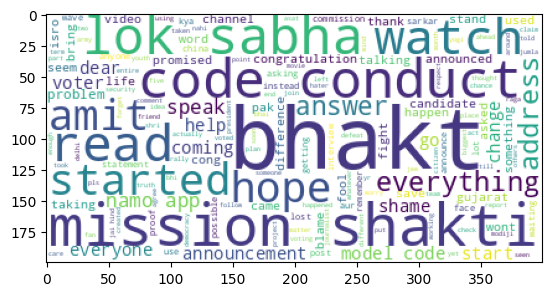

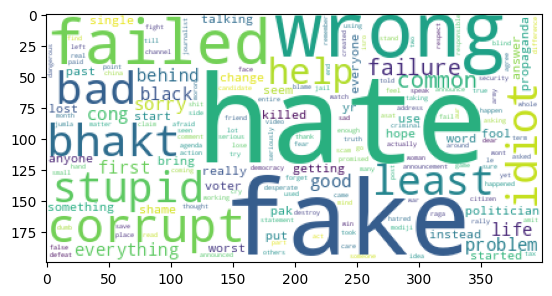

In [36]:
#checking word frequency
#for positive comments
plt.figure(1)
plt.imshow(generate_wordcloud(
    pre_dataset,
    1,
    wc,
))
#for neutral comments
plt.figure(2)
plt.imshow(generate_wordcloud(
    pre_dataset,
    0,
    wc
), )
#for negative comments
plt.figure(3)
plt.imshow(generate_wordcloud(
    pre_dataset,
    -1,
    wc
))
plt.show()

In [35]:
pre_dataset.to_excel(os.path.join(workDir,"pre_dataset.xlsx"), "Sheet1")

#Word Embedding

In [ ]:
!pip install fasttext
import fasttext

In [ ]:
train_corpus = ". ".join(list ( pre_dataset["preprocessed_text"] ))
train_corpus = train_corpus.encode(encoding = "UTF-8", errors = "strict")

In [ ]:
def train_fasttext (func, corpus, *args, **kwargs) :

  #saving encoded corpus in a temporary file
  file_path = os.path.join(workDir, "temp_corpus.txt")
  with open (file_path, "wb") as file :
    file.write(corpus)
  #creating fasttext model
  model = func(input=file_path, *args, **kwargs)
  os.remove(file_path)
  return model

In [ ]:
emb_model = train_fasttext(fasttext.train_unsupervised, train_corpus, dim= 64, model = "skipgram" )

In [ ]:
emb_model.save_model(os.path.join(workDir,"fasttext_model.bin" ))